# model evaluations  

here, we'll take a look at our trained models (between audio-only and audio + metadata features) to see which one does the best job at explaining the dataset.

## how to choose?  

we'll take an approach of comparing RMSE and R^2 scores as well as a visual check on how well our model fits the observed distributions.

some notes on the above metrics,

- RMSE (root mean squared error) tells us how close our predictions are to the actual values. **a lower RMSE indicates better performance**.

- $R^2$ tells us what proportion of variance our models explains. **a higher R^2 indicates better performance**.

## setup + load artifacts

In [2]:
from pathlib import Path
from pprint import pprint

import joblib
import matplotlib.pyplot as plt
import pandas as pd
# import shap
from src.model_training.evaluate_model import compute_model_performance


In [3]:
# path constants
BASE_MODEL_ARTIFACTS_PATH = Path(".") / "model_artifacts"
ALL_FEATURES_MODEL_ARTIFACTS_PATH = BASE_MODEL_ARTIFACTS_PATH / "all_features"
AUDIO_FEATURES_MODEL_ARTIFACTS_PATH = BASE_MODEL_ARTIFACTS_PATH / "audio_features"

# load all_features data
all_features_train_features = pd.read_csv(
    ALL_FEATURES_MODEL_ARTIFACTS_PATH / "train_features.csv", index_col='track_id'
)
all_features_train_response = pd.read_csv(
    ALL_FEATURES_MODEL_ARTIFACTS_PATH / "train_response.csv", index_col='track_id'
)
all_features_test_features = pd.read_csv(
    ALL_FEATURES_MODEL_ARTIFACTS_PATH / "test_features.csv", index_col='track_id'
)
all_features_test_response = pd.read_csv(
    ALL_FEATURES_MODEL_ARTIFACTS_PATH / "test_response.csv", index_col='track_id'
)
all_features_train_times = pd.read_csv(
    ALL_FEATURES_MODEL_ARTIFACTS_PATH / "train_times_df.csv"
)

# load audio_features data
audio_features_train_features = pd.read_csv(
    AUDIO_FEATURES_MODEL_ARTIFACTS_PATH / "train_features.csv"
)
audio_features_train_response = pd.read_csv(
    AUDIO_FEATURES_MODEL_ARTIFACTS_PATH / "train_response.csv"
)
audio_features_test_features = pd.read_csv(
    AUDIO_FEATURES_MODEL_ARTIFACTS_PATH / "test_features.csv"
)
audio_features_test_response = pd.read_csv(
    AUDIO_FEATURES_MODEL_ARTIFACTS_PATH / "test_response.csv"
)

# load all_features models
all_features_elastic_net_model = joblib.load(
    ALL_FEATURES_MODEL_ARTIFACTS_PATH / "elastic_net_model.joblib"
)
all_features_poisson_glm_model = joblib.load(
    ALL_FEATURES_MODEL_ARTIFACTS_PATH / "poisson_glm_model.joblib"
)
all_features_random_forest_model = joblib.load(
    ALL_FEATURES_MODEL_ARTIFACTS_PATH / "random_forest_model.joblib"
)
all_features_hist_gbm_model = joblib.load(
    ALL_FEATURES_MODEL_ARTIFACTS_PATH / "hist_gbm_model.joblib"
)

# load audio_features models
audio_features_elastic_net_model = joblib.load(
    AUDIO_FEATURES_MODEL_ARTIFACTS_PATH / "elastic_net_model.joblib"
)
audio_features_poisson_glm_model = joblib.load(
    AUDIO_FEATURES_MODEL_ARTIFACTS_PATH / "poisson_glm_model.joblib"
)
audio_features_random_forest_model = joblib.load(
    AUDIO_FEATURES_MODEL_ARTIFACTS_PATH / "random_forest_model.joblib"
)
audio_features_hist_gbm_model = joblib.load(
    AUDIO_FEATURES_MODEL_ARTIFACTS_PATH / "hist_gbm_model.joblib"
)

## next steps

1. for each model, add a section that displays the metrics and plot and add some notes on the fit
2. choose the best model and fit it on the entire dataset
3. show final performance from training that and save model

after, start on scoring dancehall tracks notebook

## all features models

taking a look at models that include audio + metadata features.

### elastic net linear regression  

this is our simplest benchmark model and [elastic net](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html) is a linear regression model that combines LASSO and Ridge regression which are also linear regressions that use regularization terms to prevent over-fitting.

#### some notes on the model fit  

this algorithm is very **quick to train**, taking only ~ 7s to fit 400 models.

it also shows similar performance between the train & test sets meaning it is **likely not overfitting**.

however, the metrics themselves aren't too great as the $R^2$ is quite low indicating **this model is not doing a great job at explaining the variance** in the response. 

this can also be confirmed by the visual check as the model's prediction don't spread as much as the observed distribution.

{'test_r2': 0.09696726101057696,
 'test_rmse': 15.831139925636199,
 'train_r2': 0.11774815710600983,
 'train_rmse': 15.928431284050424,
 'training_time_seconds': 7.073180743005651}


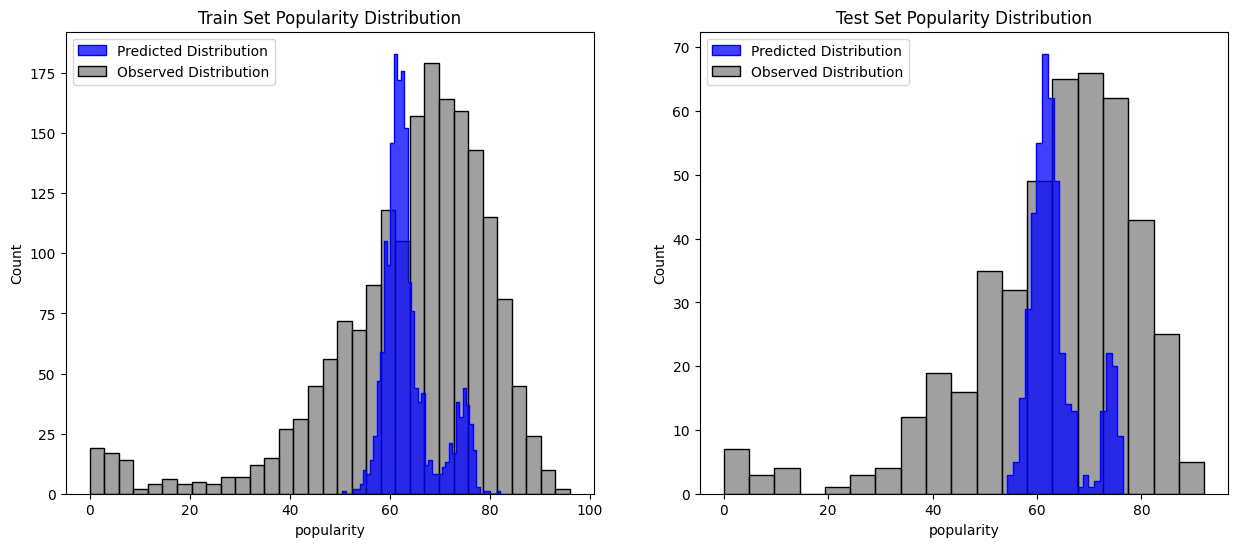

In [4]:
# make predictions
all_features_elastic_net_train_predictions = pd.DataFrame(
    {
        "expected_popularity": all_features_elastic_net_model.predict(all_features_train_features)
    }, index=all_features_train_features.index
)
all_features_elastic_net_test_predictions = pd.DataFrame(
    {
        "expected_popularity": all_features_elastic_net_model.predict(all_features_test_features)
    }, index=all_features_test_features.index
)

# get training time
all_features_elastic_net_train_time = all_features_train_times[all_features_train_times['model'] == 'elastic_net']['train_time'].iloc[0]

# compute metrics
all_features_elastic_net_metrics, all_features_elastic_net_plot_axes = compute_model_performance(
    train_predictions=all_features_elastic_net_train_predictions,
    train_response=all_features_train_response,
    test_predictions=all_features_elastic_net_test_predictions,
    test_response=all_features_test_response,
    train_time=all_features_elastic_net_train_time,
)

pprint(all_features_elastic_net_metrics)

### poisson glm  

now, we'll take a look at the poisson glm.  

the motivation for choosing this model is that we can also think of `popularity` as a count-type variable *(e.g. how many plays a certain song gets within some timeframe)*.

compared to the elastic net, this model assumes `popularity` follows a Poisson distribution as opposed to a Normal distribution.

similar to elastic net, we include an $\alpha$ term for regularization.

#### some notes on the model fit

interestingly, this model is **much slower to fit than the elastic net**, taking ~ 63s to fit 20 models while giving similar performance on train & test sets.

{'test_r2': 0.08397245011358723,
 'test_rmse': 15.944639603690408,
 'train_r2': 0.1341662182690344,
 'train_rmse': 15.779527056267359,
 'training_time_seconds': 64.50686294999468}


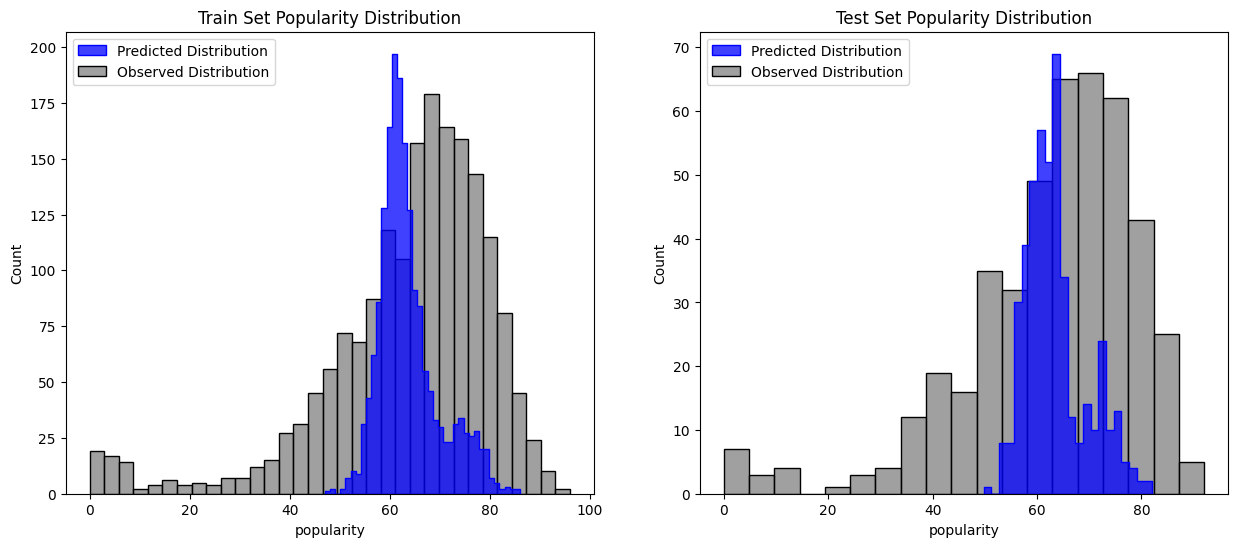

In [5]:
# make predictions
all_features_poisson_glm_train_predictions = pd.DataFrame(
    {
        "expected_popularity": all_features_poisson_glm_model.predict(all_features_train_features)
    }, index=all_features_train_features.index
)
all_features_poisson_glm_test_predictions = pd.DataFrame(
    {
        "expected_popularity": all_features_poisson_glm_model.predict(all_features_test_features)
    }, index=all_features_test_features.index
)

# get training time
all_features_poisson_glm_train_time = all_features_train_times[all_features_train_times['model'] == 'poisson_glm']['train_time'].iloc[0]

# compute metrics
all_features_poisson_glm_metrics, all_features_poisson_glm_plot_axes = compute_model_performance(
    train_predictions=all_features_poisson_glm_train_predictions,
    train_response=all_features_train_response,
    test_predictions=all_features_poisson_glm_test_predictions,
    test_response=all_features_test_response,
    train_time=all_features_poisson_glm_train_time,
)

pprint(all_features_poisson_glm_metrics)

### random forest w/ poisson criteria  

a [random forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) is an ensemble algorithm where a meta model is fit on a set of underlying decision trees, and its non-linearity is great for our use case.

here, we have a wide variety of hyper-parameters to tune but we'll limit our scope to just the following ones.

* `n_estimators` - number of trees in the forest
* `max_depth` - maximum depth of the tree

because of the way decision trees are created, they can be very prone to over-fitting and so the hyper-params we chose above are good enough ones to help mitigate that.

we'll also use the `poisson` criteria to fit our model because of our assumption on modelling `popularity` as count data.  

#### some notes on the model fit

this algorithm **took the longest to run the cross-validation scheme** - ~ 304s to fit 200 models.

however, it blew the linear models out of the water with **a much stronger $R^2$ and RMSE value** on both the train and test sets.

the visual check also confirms the better performance and interestingly, it also picked up on the values close to zero for the `popularity` column.

{'test_r2': 0.43464966684434025,
 'test_rmse': 12.526197814853832,
 'train_r2': 0.6444049826654359,
 'train_rmse': 10.112407280723069,
 'training_time_seconds': 288.35917023899674}


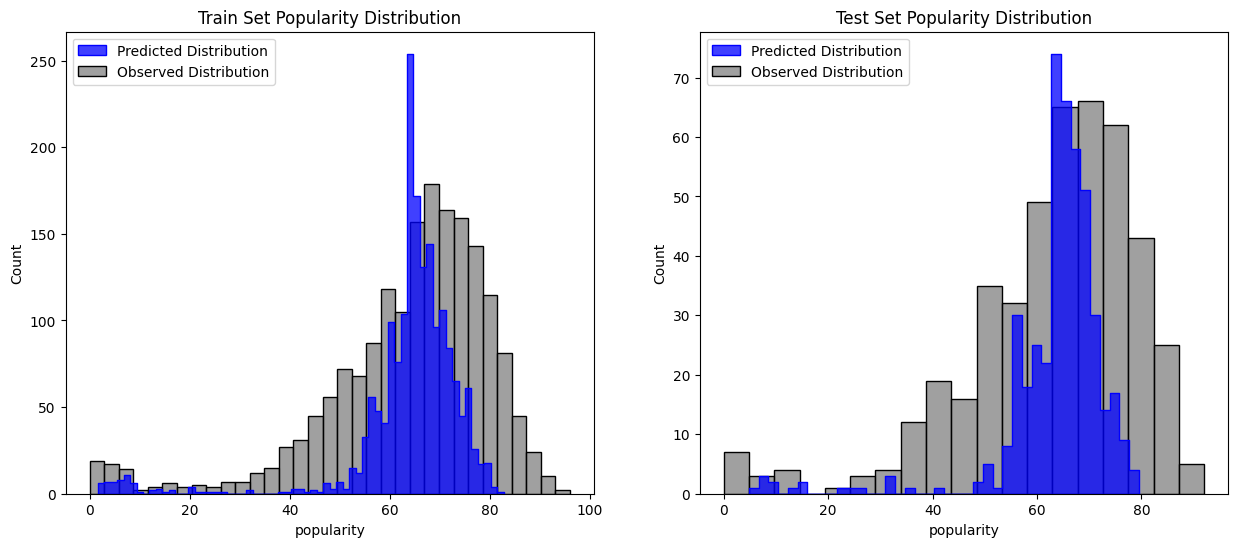

In [6]:
# make predictions
all_features_random_forest_train_predictions = pd.DataFrame(
    {
        "expected_popularity": all_features_random_forest_model.predict(all_features_train_features)
    }, index=all_features_train_features.index
)
all_features_random_forest_test_predictions = pd.DataFrame(
    {
        "expected_popularity": all_features_random_forest_model.predict(all_features_test_features)
    }, index=all_features_test_features.index
)

# get training time
all_features_random_forest_train_time = all_features_train_times[all_features_train_times['model'] == 'random_forest']['train_time'].iloc[0]

# compute metrics
all_features_random_forest_metrics, all_features_random_forest_plot_axes = compute_model_performance(
    train_predictions=all_features_random_forest_train_predictions,
    train_response=all_features_train_response,
    test_predictions=all_features_random_forest_test_predictions,
    test_response=all_features_test_response,
    train_time=all_features_random_forest_train_time,
)

pprint(all_features_random_forest_metrics)

### histogram-based gradient boosting model (hist-gbm)  

the [histogram-based gradient boosting model](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor.html) is a variant of gradient boosting that uses histograms to represent the data as opposed to individual samples. 

additionally, it builds trees vertically *(as opposed to horizontally which is usually done for other decision trees)* so this combined with the binning of samples means it trains much faster than its peers.

this implementation is also inspired by Microsoft's LightGBM algorithm.  

#### some notes on the model fit

as promised, this model trains **very fast** - ~ 66s for 600 models.

it also has the **best training performance** for both $R^2$ and RMSE while performing **similar to the random forest on the test set**.

the visual check confirms the training fit is excellent and while it may look like over-fitting, the test set performance confirms that the model generalizes well.

{'test_r2': 0.42536016017878797,
 'test_rmse': 12.628690092294779,
 'train_r2': 0.8676182471652771,
 'train_rmse': 6.170079825762482,
 'training_time_seconds': 66.15883736500109}


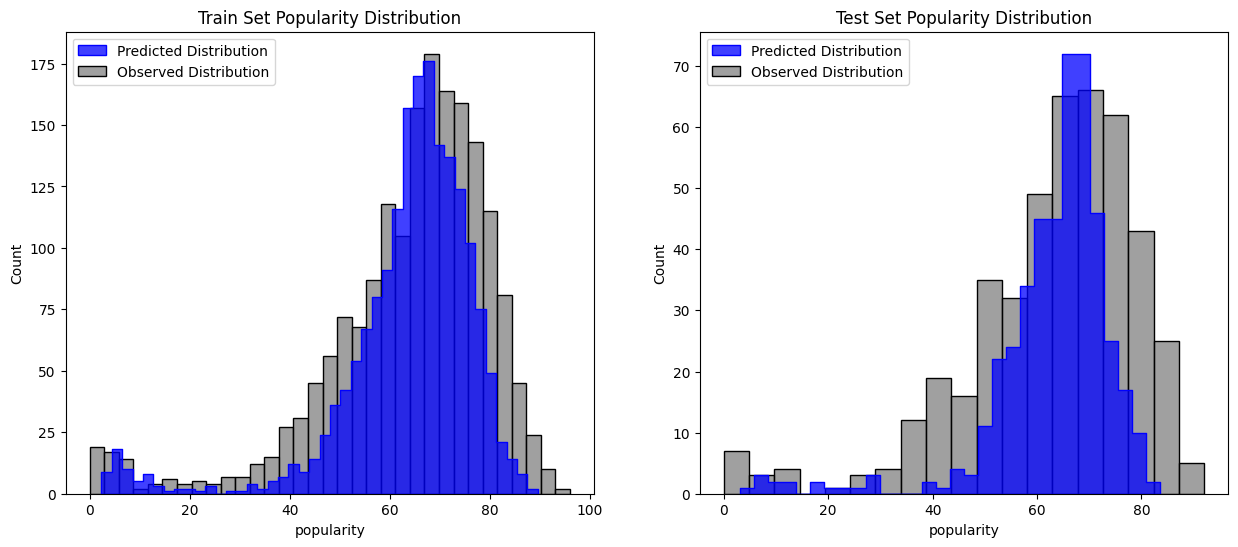

In [7]:
# make predictions
all_features_hist_gbm_train_predictions = pd.DataFrame(
    {
        "expected_popularity": all_features_hist_gbm_model.predict(all_features_train_features)
    }, index=all_features_train_features.index
)
all_features_hist_gbm_test_predictions = pd.DataFrame(
    {
        "expected_popularity": all_features_hist_gbm_model.predict(all_features_test_features)
    }, index=all_features_test_features.index
)

# get training time
all_features_hist_gbm_train_time = all_features_train_times[all_features_train_times['model'] == 'hist_gbm']['train_time'].iloc[0]

# compute metrics
all_features_hist_gbm_metrics, all_features_hist_gbm_plot_axes = compute_model_performance(
    train_predictions=all_features_hist_gbm_train_predictions,
    train_response=all_features_train_response,
    test_predictions=all_features_hist_gbm_test_predictions,
    test_response=all_features_test_response,
    train_time=all_features_hist_gbm_train_time,
)

pprint(all_features_hist_gbm_metrics)

### best model  

the `hist-gbm` is our clear winner since it has the **best metrics** for RMSE and R^2 on the test set *(and also train set)* and **a decently low training time**.

In [8]:
all_features_final_metrics = pd.DataFrame([
    all_features_elastic_net_metrics,
    all_features_poisson_glm_metrics,
    all_features_random_forest_metrics,
    all_features_hist_gbm_metrics,
], index=['elastic_net', 'poisson_glm', 'random_forest', 'hist_gbm']).sort_values(by=['test_rmse', 'test_r2', 'training_time_seconds']).round(decimals=3)
all_features_final_metrics

,train_rmse,train_r2,test_rmse,test_r2,training_time_seconds
random_forest,10.112,0.644,12.526,0.435,288.359
hist_gbm,6.170,0.868,12.629,0.425,66.159
elastic_net,15.928,0.118,15.831,0.097,7.073
poisson_glm,15.780,0.134,15.945,0.084,64.507


now, we'll refit this model on the entire dataset and take a look at the feature importance using [SHAP values](https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html). *(we'll also use this in our analysis of the dancehall tracks to better understand how the features play a role in generating the final prediction)*

## audio features models

taking a look at models that only audio features.

{'test_r2': 0.42536016017878797,
 'test_rmse': 12.628690092294779,
 'train_r2': 0.8676182471652771,
 'train_rmse': 6.170079825762482,
 'training_time_seconds': 66.15883736500109}


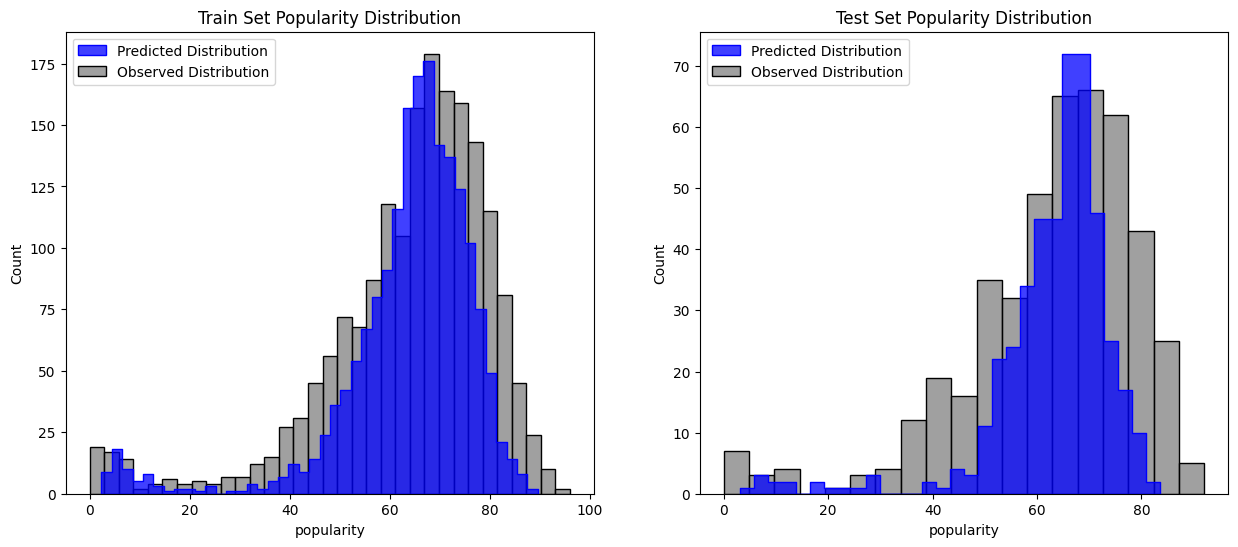

In [9]:
# make predictions
all_features_hist_gbm_train_predictions = pd.DataFrame(
    {
        "expected_popularity": all_features_hist_gbm_model.predict(all_features_train_features)
    }, index=all_features_train_features.index
)
all_features_hist_gbm_test_predictions = pd.DataFrame(
    {
        "expected_popularity": all_features_hist_gbm_model.predict(all_features_test_features)
    }, index=all_features_test_features.index
)

# get training time
all_features_hist_gbm_train_time = all_features_train_times[all_features_train_times['model'] == 'hist_gbm']['train_time'].iloc[0]

# compute metrics
all_features_hist_gbm_metrics, all_features_hist_gbm_plot_axes = compute_model_performance(
    train_predictions=all_features_hist_gbm_train_predictions,
    train_response=all_features_train_response,
    test_predictions=all_features_hist_gbm_test_predictions,
    test_response=all_features_test_response,
    train_time=all_features_hist_gbm_train_time,
)

pprint(all_features_hist_gbm_metrics)